# 000978 stage 6c — sleep projection into the awake manifold

From `src/000978/06c_sleep_projection.py`. Sleep-epoch population activity is
projected into each file's awake (run) PCA manifold to ask whether sleep samples
the same geometry as awake behavior, and in compressed/distorted form.

Metrics (per file, region):
- **occupancy** — sleep→awake nearest-neighbour distance ÷ awake self-spacing
  (~1 = sleep sits within the awake manifold), vs. a per-unit time-shuffle null
- **replay index** = shuffle ÷ real (>1 = sleep closer than chance, i.e.
  co-activation structure)
- **compression** — sleep spread ÷ awake spread per awake PC (<1 = compressed)

> **Timescale caveat.** These use the 1000 ms bins chosen for the awake manifold.
> Hippocampal replay lives at ~100-200 ms (sharp-wave ripples); at 1 s it is
> averaged out. So a null replay index here is expected and does **not** rule out
> replay — a proper test needs fine bins / SWR-triggered analysis.


## Setup

In [1]:
import sys, pathlib
_root = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
             if (p / "src" / "common" / "config.py").exists())
for _d in ("common", "000978"):
    sys.path.insert(0, str(_root / "src" / _d))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from config import processed_dir, load_rate_matrix, BIN_SIZE_S
DATA_PROCESSED = processed_dir("000978")
BIN_MS = int(BIN_SIZE_S * 1000)
REGION_COLOR = {"CA1": "tab:blue", "PFC": "tab:red"}
plt.rcParams["figure.dpi"] = 100
df = pd.read_csv(DATA_PROCESSED / f"stage6c_sleep_projection_{BIN_MS}ms.csv")
df.round(3)

,session_key,region,n_run,n_sleep,k_dim,occupancy_real,occupancy_shuffle,replay_index,compression
0,ER1,CA1,7627,11673,10,1.228,1.233,1.004,0.607
1,ER1,PFC,7627,11673,10,0.888,0.872,0.981,0.607
2,JS14,CA1,7350,10424,10,0.882,0.903,1.024,0.642
3,JS14,PFC,7350,10424,10,0.892,0.905,1.015,0.658
4,JS15,CA1,7714,13575,10,1.017,1.027,1.009,0.582
5,JS15,PFC,7714,13575,10,1.561,1.597,1.024,0.707
6,JS17,CA1,7649,13892,10,1.274,1.231,0.966,0.756
7,JS17,PFC,7649,13892,10,1.157,1.155,0.998,0.856
8,JS21,CA1,7811,12069,10,1.157,1.134,0.980,0.894
9,JS21,PFC,7811,12069,10,1.320,1.296,0.982,0.682


## 1. Occupancy: is sleep on the awake manifold, and is it structured?

Left: sleep occupancy (real) vs. its shuffle — points on the diagonal mean the
per-unit time-shuffle doesn't change occupancy (no co-activation-specific signal
at 1 s). Occupancy near 1 means sleep sits about as close to the awake manifold
as awake points sit to each other.

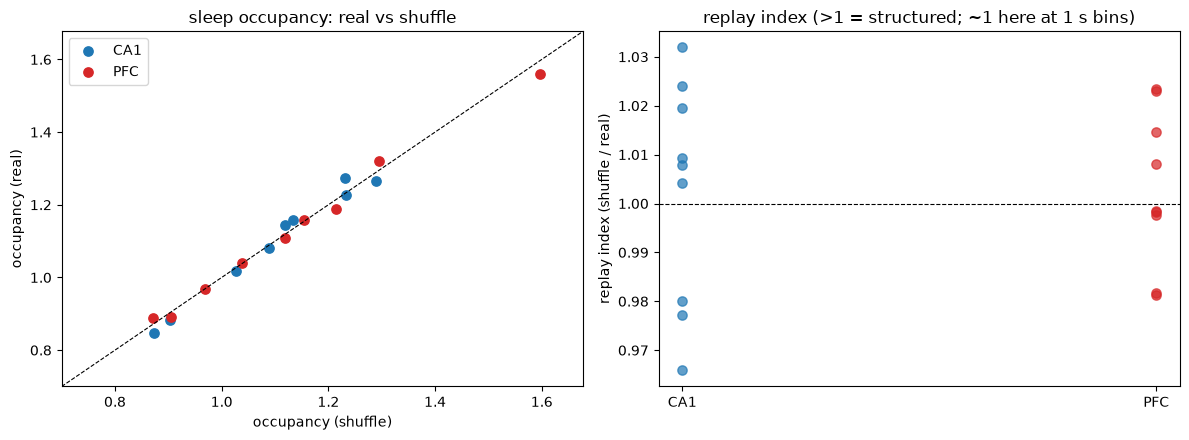

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for region in ["CA1", "PFC"]:
    r = df[df.region == region]
    axes[0].scatter(r.occupancy_shuffle, r.occupancy_real, color=REGION_COLOR[region], s=45, label=region)
lim = [0.7, max(df.occupancy_real.max(), df.occupancy_shuffle.max()) * 1.05]
axes[0].plot(lim, lim, "k--", lw=0.8); axes[0].set_xlim(lim); axes[0].set_ylim(lim)
axes[0].set_xlabel("occupancy (shuffle)"); axes[0].set_ylabel("occupancy (real)")
axes[0].set_title("sleep occupancy: real vs shuffle"); axes[0].legend()
axes[1].axhline(1, color="k", ls="--", lw=0.8)
for region in ["CA1", "PFC"]:
    r = df[df.region == region]
    axes[1].scatter([region] * len(r), r.replay_index, color=REGION_COLOR[region], s=45, alpha=0.7)
axes[1].set_ylabel("replay index (shuffle / real)")
axes[1].set_title("replay index (>1 = structured; ~1 here at 1 s bins)")
plt.tight_layout()

## 2. Compression: sleep samples a shrunken manifold

Sleep spread ÷ awake spread per awake PC. All well below 1 — sleep activity
projects onto the awake manifold in a **compressed** form, the geometric
"compressed/distorted version" the study asks about.

mean compression  CA1: 0.645 | PFC: 0.701


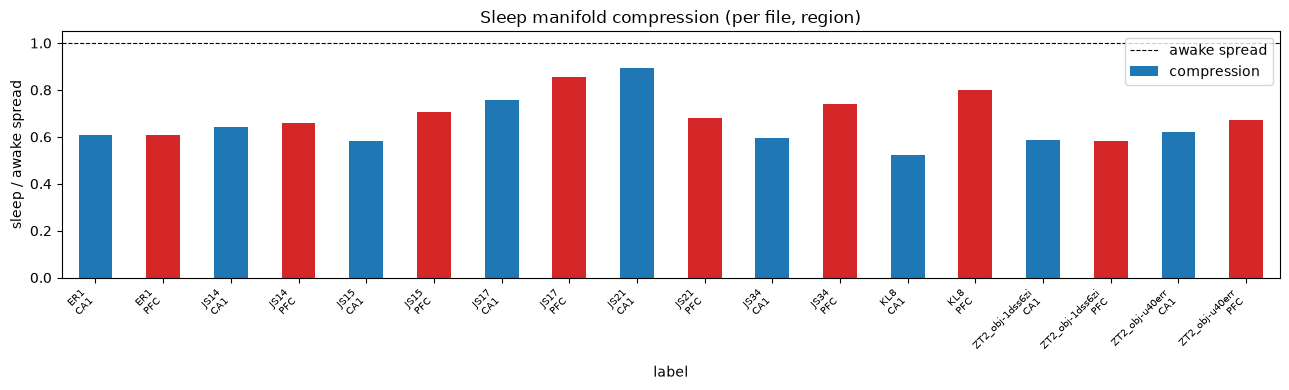

In [3]:
df2 = df.copy(); df2["label"] = df2.session_key + "\n" + df2.region
ax = df2.set_index("label")["compression"].plot.bar(
    figsize=(13, 4), color=[REGION_COLOR[r] for r in df2.region])
ax.axhline(1, color="k", ls="--", lw=0.8, label="awake spread")
ax.set_ylabel("sleep / awake spread"); ax.set_title("Sleep manifold compression (per file, region)")
plt.xticks(rotation=45, ha="right", fontsize=7); ax.legend(); plt.tight_layout()
print("mean compression  CA1:", round(df[df.region=='CA1'].compression.mean(), 3),
      "| PFC:", round(df[df.region=='PFC'].compression.mean(), 3))

## 3. Visualize one session: sleep overlaid on the awake manifold

Awake (grey) and sleep (orange) bins projected into the awake PC1-PC2 plane.
Sleep sits within, but occupies a smaller region of, the awake manifold.

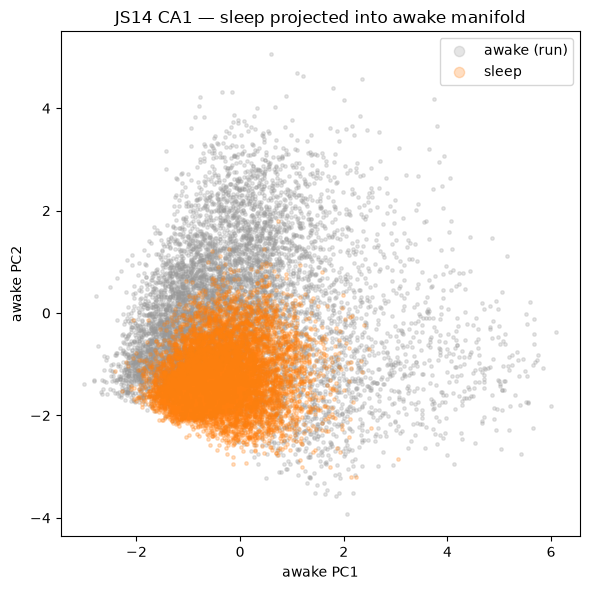

In [4]:
from sklearn.decomposition import PCA
keys = sorted({f.stem.split("_")[1] for f in DATA_PROCESSED.glob(f"rates_*_{BIN_MS}ms.npz")})
SESSION, REGION = "JS14", "CA1"
d = load_rate_matrix(SESSION, REGION, BIN_MS, "000978")
run, sleep = d["kind"] == "run", d["kind"] == "sleep"
X = d["rates"].astype(float)
pca = PCA(n_components=2).fit(X[run])
zr, zs = pca.transform(X[run]), pca.transform(X[sleep])
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(zr[:, 0], zr[:, 1], s=6, alpha=0.25, color="0.6", label="awake (run)")
ax.scatter(zs[:, 0], zs[:, 1], s=6, alpha=0.25, color="tab:orange", label="sleep")
ax.set_xlabel("awake PC1"); ax.set_ylabel("awake PC2"); ax.legend(markerscale=3)
ax.set_title(f"{SESSION} {REGION} — sleep projected into awake manifold")
plt.tight_layout()

---
**Result:** sleep population activity projects onto the awake manifold
(occupancy ~1) in a **compressed** form (~65% of awake spread), but shows no
co-activation-specific replay signal **at 1 s bins** (replay index ~1) — the
latter is the wrong timescale for ripple replay. A finer-bin / SWR-triggered
version of this projection is the natural follow-up.

This completes the 000978 pipeline: extraction -> baselines -> embeddings ->
6b learning trajectory -> 6c sleep projection.